In [76]:
# -------------------------------
# IMPORTS
# -------------------------------
import pandas as pd
import numpy as np
import re
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix, roc_curve
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

In [77]:
# -------------------------------
# PREPROCESSING FUNCTION (your friend's code)
# -------------------------------
def convert_range_to_midpoint(value):
    """
    Cleans a string, converts ranges to their midpoint, and handles various formats.
    """
    s = str(value).lower()
    s = s.replace('$', '').replace(',', '').replace('+', '')
    s = re.sub(r'k', '000', s)

    if '-' in s:
        try:
            parts = s.split('-')
            start = float(parts[0].strip())
            end = float(parts[1].strip())
            return (start + end) / 2
        except (ValueError, IndexError):
            return 0
    
    try:
        return float(s.strip())
    except ValueError:
        return 0


def preprocessing_data(df, target_col="Churn", drop_cols=[], categorical_encoder='ordinal'):
    print("🔧 Starting Preprocessing...")

    all_cols_to_drop = [col for col in df.columns if col.lower().endswith('_id')]
    if 'Id' in df.columns and 'Id' not in all_cols_to_drop:
        all_cols_to_drop.append('Id')
    all_cols_to_drop.extend(drop_cols)

    existing_cols_to_drop = [col for col in all_cols_to_drop if col in df.columns]
    if existing_cols_to_drop:
        print(f"Dropping columns: {existing_cols_to_drop}")
        df = df.drop(columns=existing_cols_to_drop)

    if target_col not in df.columns:
        raise ValueError(f"Target column '{target_col}' not found in the DataFrame.")

    # Handle home_market_value
    if "home_market_value" in df.columns:
        if 'home_owner' in df.columns:
            df.loc[df['home_owner'] == 0, 'home_market_value'] = '0'
        df['home_market_value'] = df['home_market_value'].fillna('0')
        df['home_market_value'] = df['home_market_value'].apply(convert_range_to_midpoint)

    # Drop missing rows
    df = df.dropna()

    X = df.drop(columns=[target_col])
    y = df[target_col]

    # Encode categorical variables
    categorical_cols = X.select_dtypes(include=['object', 'category']).columns
    if categorical_encoder == 'onehot':
        print(f"Applying One-Hot Encoding to: {list(categorical_cols)}")
        X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)
    elif categorical_encoder == 'ordinal':
        print(f"Applying Ordinal Encoding to: {list(categorical_cols)}")
        if not categorical_cols.empty:
            encoder = OrdinalEncoder()
            X[categorical_cols] = encoder.fit_transform(X[categorical_cols])
    else:
        raise ValueError("Invalid categorical_encoder. Choose 'onehot' or 'ordinal'.")

    # Scale numerical columns
    print("Applying StandardScaler...")
    scaler = StandardScaler()
    numerical_cols = X.select_dtypes(include=np.number).columns
    if not numerical_cols.empty:
        X[numerical_cols] = scaler.fit_transform(X[numerical_cols])

    print("✅ Preprocessing complete.")
    return X, y, scaler

In [ ]:
# -------------------------------
# LOAD DATA
# -------------------------------
insurance_df = pd.read_csv("autoinsurance_churn.csv")

# Apply preprocessing
X, y, scaler = preprocessing_data(
    insurance_df,
    drop_cols=["latitude", "longitude", "county", "state", "cust_orig_date", "date_of_birth", "acct_suspd_date"],
    categorical_encoder='onehot'
)



🔧 Starting Preprocessing...
Dropping columns: ['individual_id', 'address_id', 'latitude', 'longitude', 'county', 'state', 'cust_orig_date', 'date_of_birth', 'acct_suspd_date']
Applying One-Hot Encoding to: ['city', 'marital_status']
Applying StandardScaler...
✅ Preprocessing complete.
Number of unique rows: 1668842
Sum of Churn after removing duplicates: 192003

⚖️ Balancing data using SMOTE...
Before SMOTE: {0: 1476839, 1: 192003}
After SMOTE: {0: 1476839, 1: 1476839}

Number of rows after SMOTE & removing duplicates: 2953678 (2953678, 105)
Sum of Churn after SMOTE & removing duplicates: 1476839 (2953678,)


In [ ]:
# -------------------------------
# IMPORTS
# -------------------------------
import pandas as pd
import numpy as np
import re
import random
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score
import joblib

# -------------------------------
# PREPROCESSING UTILITY
# -------------------------------
def convert_range_to_midpoint(value):
    s = str(value).lower().replace('$', '').replace(',', '').replace('+', '')
    s = re.sub(r'k', '000', s)
    if '-' in s:
        try:
            parts = s.split('-')
            return (float(parts[0].strip()) + float(parts[1].strip())) / 2
        except (ValueError, IndexError):
            return 0
    try:
        return float(s.strip())
    except ValueError:
        return 0

# -------------------------------
# HYPERPARAMETERS & CONFIG
# -------------------------------
SEED = 42
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-2  # <-- Increased from 1e-5 for stronger L2 regularization
DROPOUT_RATE = 0.3   # <-- Explicitly defined dropout rate
EPOCHS = 100
BATCH_SIZE = 256
EARLY_STOP_PATIENCE = 100

# -------------------------------
# REPRODUCIBILITY
# -------------------------------
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# -------------------------------
# STEP 1: LOAD AND CLEAN DATA (WITHOUT SCALING)
# -------------------------------
print("🔧 Starting Data Loading and Cleaning...")
df = pd.read_csv("autoinsurance_churn.csv")

# Drop specified and ID columns
drop_cols = ["latitude", "longitude", "county", "state", "cust_orig_date", "date_of_birth", "acct_suspd_date"]
all_cols_to_drop = [col for col in df.columns if col.lower().endswith('_id')]
if 'Id' in df.columns and 'Id' not in all_cols_to_drop:
    all_cols_to_drop.append('Id')
all_cols_to_drop.extend(drop_cols)
existing_cols_to_drop = [col for col in all_cols_to_drop if col in df.columns]
df = df.drop(columns=existing_cols_to_drop)
print(f"Dropped columns: {existing_cols_to_drop}")

# Handle home_market_value
if "home_market_value" in df.columns:
    if 'home_owner' in df.columns:
        df.loc[df['home_owner'] == 0, 'home_market_value'] = '0'
    df['home_market_value'] = df['home_market_value'].fillna('0')
    df['home_market_value'] = df['home_market_value'].apply(convert_range_to_midpoint)

df = df.dropna()
X = df.drop(columns=['Churn'])
y = df['Churn']
categorical_cols = X.select_dtypes(include=['object', 'category']).columns
print(f"Applying One-Hot Encoding to: {list(categorical_cols)}")
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)
print("✅ Data Cleaning and Encoding complete.")

# -------------------------------
# STEP 2: SPLIT THE DATA (BEFORE SCALING)
# -------------------------------
print("🔪 Splitting data into train, validation, and test sets...")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=SEED, stratify=y_train)
print(f"Train shape: {X_train.shape}, Val shape: {X_val.shape}, Test shape: {X_test.shape}")

# -------------------------------
# STEP 3: SCALE THE DATA (CORRECT WORKFLOW)
# -------------------------------
print("📏 Scaling numerical features...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)
print("✅ Scaler fitted on training data.")

# -------------------------------
# STEP 4: PYTORCH DATA SETUP
# -------------------------------
y_train = y_train.values.astype(np.float32)
y_val   = y_val.values.astype(np.float32)
y_test  = y_test.values.astype(np.float32)

class TabularDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).view(-1, 1)
    def __len__(self):
        return len(self.y)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_loader = DataLoader(TabularDataset(X_train_scaled, y_train), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(TabularDataset(X_val_scaled, y_val), batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(TabularDataset(X_test_scaled, y_test), batch_size=BATCH_SIZE, shuffle=False)

# -------------------------------
# STEP 5: PYTORCH MODEL, LOSS, AND OPTIMIZER
# -------------------------------
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dims=[256, 128, 64], dropout=0.3):
        super().__init__()
        layers = []
        d_in = input_dim
        for h in hidden_dims:
            layers.append(nn.Linear(d_in, h))
            layers.append(nn.ReLU())
            layers.append(nn.BatchNorm1d(h))
            layers.append(nn.Dropout(p=dropout))
            d_in = h
        layers.append(nn.Linear(d_in, 1))
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x)

# Use hyperparameters from the config section
model = MLP(input_dim=X_train_scaled.shape[1], hidden_dims=[256, 128, 64], dropout=DROPOUT_RATE).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=4)

# -------------------------------
# STEP 6: MODEL TRAINING AND EVALUATION
# -------------------------------
def evaluate(model, loader, criterion, device):
    model.eval()
    ys, probs = [], []
    losses = []
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            prob = torch.sigmoid(logits).cpu().numpy().flatten()
            probs.append(prob)
            ys.append(yb.cpu().numpy().flatten())
            loss_batch = criterion(logits, yb).item()
            losses.append(loss_batch)
    y_true = np.concatenate(ys)
    y_prob = np.concatenate(probs)
    avg_loss = np.mean(losses)
    auc = roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else 0.5
    y_pred_label = (y_prob >= 0.5).astype(int)
    acc = accuracy_score(y_true, y_pred_label)
    prec = precision_score(y_true, y_pred_label, zero_division=0)
    rec = recall_score(y_true, y_pred_label, zero_division=0)
    return {"loss": avg_loss, "auc": auc, "acc": acc, "prec": prec, "rec": rec}

best_val_loss = float('inf')
epochs_no_improve = 0
best_state = None

print("\n🚀 Starting model training...")
for epoch in range(1, EPOCHS + 1):
    model.train()
    epoch_losses = []
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        epoch_losses.append(loss.item())
    
    train_loss = np.mean(epoch_losses)
    val_metrics = evaluate(model, val_loader, criterion, device)
    val_loss = val_metrics["loss"]
    scheduler.step(val_loss)
    
    print(f"Epoch {epoch:03d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val AUC: {val_metrics['auc']:.4f}")
    
    if val_loss < best_val_loss - 1e-6:
        best_val_loss = val_loss
        epochs_no_improve = 0
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= EARLY_STOP_PATIENCE:
            print(f"🛑 Early stopping triggered after {epoch} epochs.")
            break

if best_state is not None:
    print("\nLoading best model state for final evaluation.")
    model.load_state_dict(best_state)
    model.to(device)

test_metrics = evaluate(model, test_loader, criterion, device)
print("\n--- Test Set Results ---")
print(f"Test Loss: {test_metrics['loss']:.4f}")
print(f"Test AUC:  {test_metrics['auc']:.4f}")
print(f"Test Acc:  {test_metrics['acc']:.4f} | Precision: {test_metrics['prec']:.4f} | Recall: {test_metrics['rec']:.4f}")

# -------------------------------
# STEP 7: PREDICTION FUNCTION & FINAL SAVING
# -------------------------------
def predict_proba_numpy(model, X_np, batch_size=1024):
    model.eval()
    probs = []
    with torch.no_grad():
        for i in range(0, X_np.shape[0], batch_size):
            xb = torch.tensor(X_np[i:i+batch_size], dtype=torch.float32).to(device)
            logits = model(xb)
            probs.append(torch.sigmoid(logits).cpu().numpy())
    return np.vstack(probs).flatten()

test_probs = predict_proba_numpy(model, X_test_scaled)
pd.DataFrame({"y_true": y_test, "y_prob": test_probs}).to_csv("test_predictions.csv", index=False)
print("\n✅ Test predictions saved to 'test_predictions.csv'.")

print("💾 Saving final model and scaler...")
joblib.dump(model, "mlp_model.pkl")
joblib.dump(scaler, "mlp_scaler.pkl")
print("✅ Model saved to 'mlp_model.pkl'.")
print("✅ Scaler saved to 'mlp_scaler.pkl'.")

Train shape: (1772206, 105)
Test shape: (1181472, 105)

Number of features: 105

Feature (dimension) names:
1. curr_ann_amt
2. days_tenure
3. age_in_years
4. income
5. has_children
6. length_of_residence
7. home_market_value
8. home_owner
9. college_degree
10. good_credit
11. city_Aledo
12. city_Allen
13. city_Anna
14. city_Argyle
15. city_Arlington
16. city_Aubrey
17. city_Azle
18. city_Balch Springs
19. city_Bedford
20. city_Blue Ridge
21. city_Burleson
22. city_Caddo Mills
23. city_Carrollton
24. city_Cedar Hill
25. city_Celina
26. city_Chatfield
27. city_Colleyville
28. city_Coppell
29. city_Crandall
30. city_Crowley
31. city_Dallas
32. city_Denton
33. city_Desoto
34. city_Duncanville
35. city_Ennis
36. city_Era
37. city_Euless
38. city_Farmersville
39. city_Ferris
40. city_Flower Mound
41. city_Forney
42. city_Forreston
43. city_Fort Worth
44. city_Frisco
45. city_Garland
46. city_Grand Prairie
47. city_Grapevine
48. city_Haltom City
49. city_Haslet
50. city_Hurst
51. city_Hutchin


🚀 Training XGBoost Model...


/home/bheemasiddartha/.local/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [05:37:40] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


✅ Model training complete!



✅ Accuracy: 91.32%
✅ ROC-AUC: 95.20%

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.95      0.92    590736
           1       0.94      0.88      0.91    590736

    accuracy                           0.91   1181472
   macro avg       0.92      0.91      0.91   1181472
weighted avg       0.92      0.91      0.91   1181472



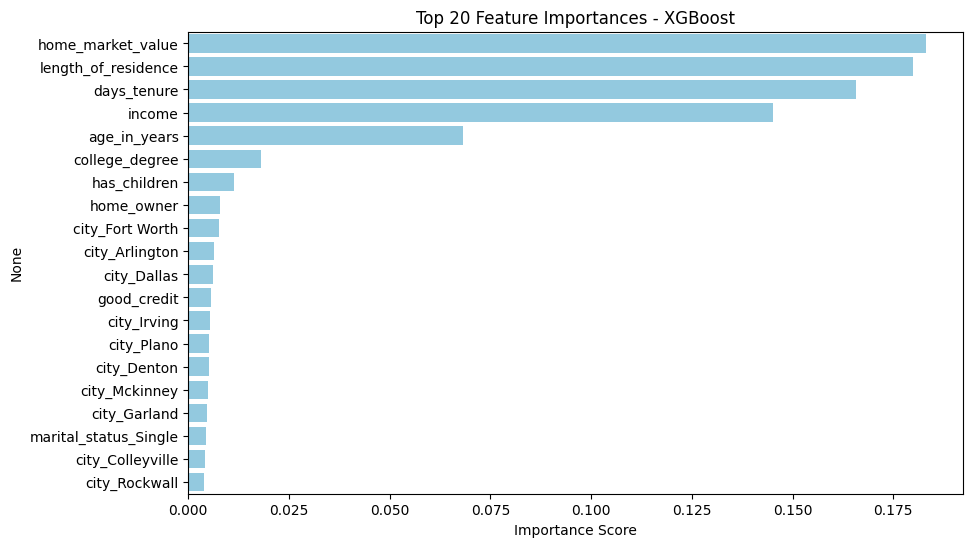


Example Customer → Churn Probability: 13.30%

💾 Model and Scaler saved successfully!
